# Session 4

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
np.random.seed(3)

## Task 1 — Boxplot: Flipkart Product Price Distribution

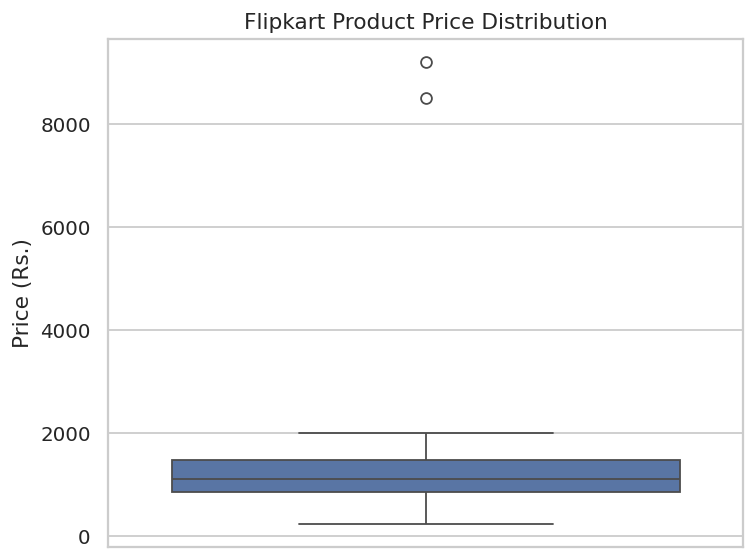

In [1]:
prices = np.concatenate([
    np.random.normal(1200, 400, 40).clip(200, None),
    [8500, 9200, 250]  # a couple of premium products + one budget outlier
]).round()
prices_df = pd.DataFrame({'price': prices})

plt.figure(figsize=(6, 4.5))
sns.boxplot(y=prices_df['price'])
plt.ylabel('Price (Rs.)')
plt.title('Flipkart Product Price Distribution')
plt.tight_layout()
plt.show()

## Task 2 — Violinplot: Order Amounts, Fast Food vs Desserts

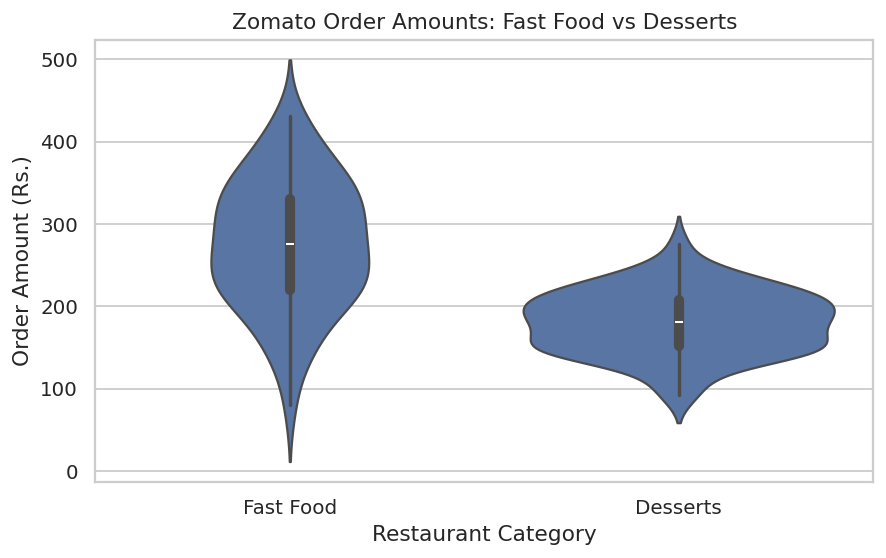

In [1]:
fastfood_amounts = np.random.normal(280, 70, 60).clip(80, None)
dessert_amounts = np.random.normal(180, 50, 60).clip(60, None)

category_df = pd.DataFrame({
    'order_amount': np.concatenate([fastfood_amounts, dessert_amounts]),
    'category': ['Fast Food'] * 60 + ['Desserts'] * 60
})

plt.figure(figsize=(7, 4.5))
sns.violinplot(data=category_df, x='category', y='order_amount')
plt.xlabel('Restaurant Category')
plt.ylabel('Order Amount (Rs.)')
plt.title('Zomato Order Amounts: Fast Food vs Desserts')
plt.tight_layout()
plt.show()

## Task 3 — Boxplot: IPL Ticket Prices, Identify Outliers

Q1: 607.5 | Q3: 727.5 | IQR: 120.0
Outlier bounds: 427.5 to 907.5
Outliers detected: [5500, 6200]


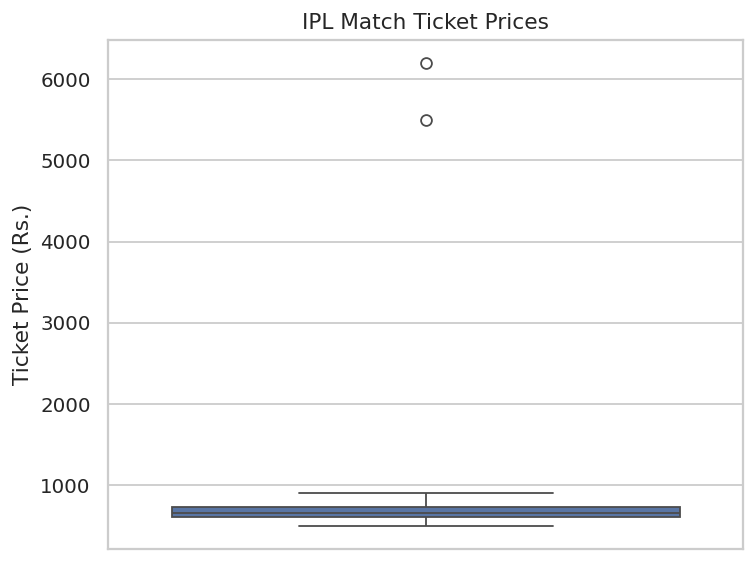

In [1]:
ticket_prices = np.array([500, 750, 600, 800, 650, 700, 550, 900, 620, 680,
                           580, 720, 640, 5500, 6200, 610, 590, 660, 630, 710])

q1 = np.percentile(ticket_prices, 25)
q3 = np.percentile(ticket_prices, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = ticket_prices[(ticket_prices < lower_bound) | (ticket_prices > upper_bound)]

plt.figure(figsize=(6, 4.5))
sns.boxplot(y=ticket_prices)
plt.ylabel('Ticket Price (Rs.)')
plt.title('IPL Match Ticket Prices')
plt.tight_layout()
plt.show()

print('Q1:', q1, '| Q3:', q3, '| IQR:', iqr)
print('Outlier bounds:', lower_bound, 'to', upper_bound)
print('Outliers detected:', outliers.tolist())

**Outliers identified:** ₹5,500 and ₹6,200 — these sit far above the upper whisker and are almost certainly premium seats (VIP/hospitality boxes) rather than standard match tickets, which otherwise cluster tightly between roughly ₹550-800.

## Task 4 — Violinplot: Daily Step Counts (Google Fit-style)

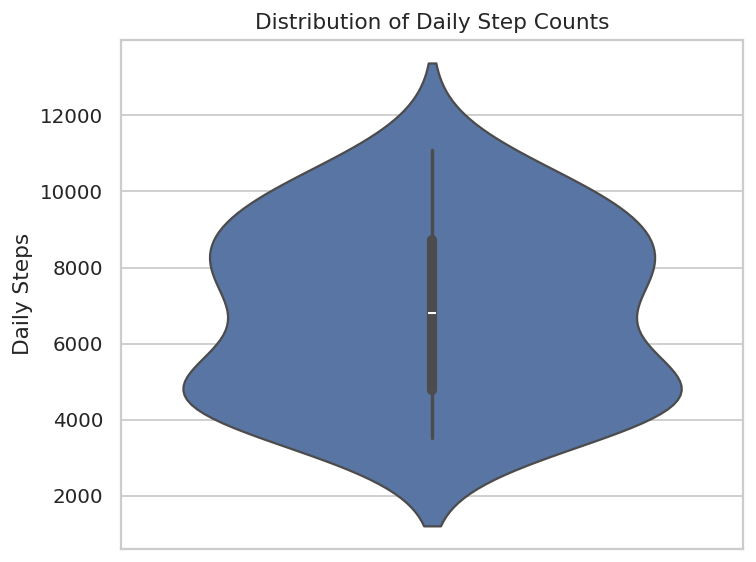

In [1]:
steps = np.concatenate([
    np.random.normal(5000, 1000, 15),   # low-activity days
    np.random.normal(9000, 1200, 15),   # high-activity days
]).clip(1000, None)

plt.figure(figsize=(6, 4.5))
sns.violinplot(y=steps)
plt.ylabel('Daily Steps')
plt.title('Distribution of Daily Step Counts')
plt.tight_layout()
plt.show()

**What the shape tells us:** the violin is clearly **bimodal** — two separate bulges rather than one smooth hump — around roughly 5,000 and 9,000 steps. That points to two distinct activity patterns for this user (e.g., sedentary weekdays vs. active weekends, or rest days vs. workout days) rather than a single 'typical' activity level with random day-to-day noise around it.